# RSA Modeling
**목표**: LLM-as-Speaker 실험 결과로 pRRSA 역추적

```
de_logit_results.csv
        ↓
[Step 1] Literal Semantics → L0 계산
        ↓
[Step 2] u_epi, u_soc 계산
        ↓
[Step 3] pRRSAc(u|s,r; λ,φ) 구현 & toy test
        ↓
[Step 4] PyMC로 λ, φ 역추적 (내일)
```

**모델**: pRRSAc (polite RSA, choice/logit data)
$$S(u \mid s, r) \propto \exp\bigl(\lambda \cdot [(1-\phi_r)\, U_{\text{epi}}(u,s) + \phi_r\, U_{\text{soc}}(u)]\bigr)$$

---
## Step 1 — Literal Semantics & L0

In [2]:
import numpy as np
import pandas as pd

# ── 실험 설정 ─────────────────────────────────────────────────────────────────
UTTERANCES = ["großartig", "gut", "okay", "schlecht", "schrecklich"]
STATES     = [1, 2, 3, 4, 5]   # 1 = worst, 5 = best
RELATIONS  = ["Enge Freundin", "Entfernte Kollegin", "Lockere Chefin", "Gefürchtete Chefin"]

# ── Literal Semantics: Lumer's 2022 독일어 replication Table 1 ───────────────────
# 참여자 acceptance proportion ("이 단어가 이 state에 맞는가?" yes 비율)
# 각 참여자는 yes/no binary로 답했지만,
# 집계된 proportion은 단어의 graded acceptability를 반영 → soft semantics로 사용
#
#                s=1    s=2    s=3    s=4    s=5
SEM = np.array([
    [0.00,  0.03,  0.06,  0.16,  1.00],   # großartig
    [0.03,  0.03,  0.66,  1.00,  0.90],   # gut
    [0.06,  0.47,  1.00,  0.66,  0.47],   # okay
    [0.91,  0.59,  0.06,  0.00,  0.00],   # schlecht
    [0.84,  0.25,  0.00,  0.00,  0.00],   # schrecklich
], dtype=float)   # shape: (n_utt=5, n_state=5)

# ── Smoothing: 0.00 → 0.01 (log(0) = -∞ 방지) ───────────────────────────────
# SEM에 0이 있으면 L0=0 → U_epi=log(0)=-∞ → RSA가 해당 조합을 완전 배제
# LLM은 0%를 부여하지 않으므로, 최소 1% floor를 적용해 불일치 완화
SEM_RAW = SEM.copy()   # 원본 보존
SEM = np.maximum(SEM, 0.01)
print(f"Smoothing 적용: {(SEM_RAW == 0).sum()}개 셀이 0.00 → 0.01로 변경됨")

# ── L0 Literal Listener: P_L0(s|u) ───────────────────────────────────────────
# P_L0(s|u) ∝ [[u]](s) · P(s)   with uniform prior P(s)
prior_s = np.ones(len(STATES)) / len(STATES)
print("PRIOR :", prior_s)

L0 = SEM * prior_s[np.newaxis, :]              # (n_utt, n_state)
print("L0 before nomalization :", L0)
row_sums = L0.sum(axis=1, keepdims=True)
#NORMALIZATION
L0 = L0 / np.where(row_sums == 0, 1, row_sums) # normalize (0-row 방지) prob distribution 만드는것 

# ── 확인 ─────────────────────────────────────────────────────────────────────
print("SEM — Table 1 acceptance proportions")
print(pd.DataFrame(SEM, index=UTTERANCES, columns=[f"s={s}" for s in STATES]).round(2).to_string())

print("\nL0 — P_L0(s | u)  [soft semantics 기반]")
print(pd.DataFrame(L0, index=UTTERANCES, columns=[f"s={s}" for s in STATES]).round(3).to_string())

Smoothing 적용: 6개 셀이 0.00 → 0.01로 변경됨
PRIOR : [0.2 0.2 0.2 0.2 0.2]
L0 before nomalization : [[0.002 0.006 0.012 0.032 0.2  ]
 [0.006 0.006 0.132 0.2   0.18 ]
 [0.012 0.094 0.2   0.132 0.094]
 [0.182 0.118 0.012 0.002 0.002]
 [0.168 0.05  0.002 0.002 0.002]]
SEM — Table 1 acceptance proportions
              s=1   s=2   s=3   s=4   s=5
großartig    0.01  0.03  0.06  0.16  1.00
gut          0.03  0.03  0.66  1.00  0.90
okay         0.06  0.47  1.00  0.66  0.47
schlecht     0.91  0.59  0.06  0.01  0.01
schrecklich  0.84  0.25  0.01  0.01  0.01

L0 — P_L0(s | u)  [soft semantics 기반]
               s=1    s=2    s=3    s=4    s=5
großartig    0.008  0.024  0.048  0.127  0.794
gut          0.011  0.011  0.252  0.382  0.344
okay         0.023  0.177  0.376  0.248  0.177
schlecht     0.576  0.373  0.038  0.006  0.006
schrecklich  0.750  0.223  0.009  0.009  0.009


---
## Step 2 — U_epi & U_soc 계산

In [3]:
# ── Epistemic Utility: U_epi(u, s) = log P_L0(s | u) ─────────────────────────
# 얼마나 '정보적'인가 — L0 가 s를 올바르게 복원할 수 있는 정도
eps = 1e-10
U_epi = np.log(L0 + eps)   # (n_utt, n_state) // eps 더하는 이유 계산 오류 방지용 

# ── Social Utility: U_soc(u) = E_L0[s | u] ───────────────────────────────────
# 얼마나 '기분 좋은' 말인가 — L0 하에서 기대 state (높을수록 좋은 말)
state_vals = np.array(STATES, dtype=float)         # [1,2,3,4,5]
U_soc = (L0 * state_vals[np.newaxis, :]).sum(axis=1)   # (n_utt,) — utterance별 한 값

# ── 확인 ─────────────────────────────────────────────────────────────────────
print("U_epi = log P_L0(s | u)")
df_uepi = pd.DataFrame(U_epi, index=UTTERANCES, columns=[f"s={s}" for s in STATES])
print(df_uepi.round(3).to_string())

print("\nU_soc = E_L0[s | u]  (the higher, the more positive)")
for u, v in zip(UTTERANCES, U_soc):
    print(f"  {u:12s}: {v:.3f}")

U_epi = log P_L0(s | u)
               s=1    s=2    s=3    s=4    s=5
großartig   -4.836 -3.738 -3.045 -2.064 -0.231
gut         -4.470 -4.470 -1.379 -0.963 -1.069
okay        -3.792 -1.733 -0.978 -1.394 -1.733
schlecht    -0.552 -0.985 -3.271 -5.063 -5.063
schrecklich -0.288 -1.500 -4.718 -4.718 -4.718

U_soc = E_L0[s | u]  (the higher, the more positive)
  großartig   : 4.675
  gut         : 4.034
  okay        : 3.380
  schlecht    : 1.494
  schrecklich : 1.304


---
## Step 3 — pRRSAc Speaker 구현 & Toy Test

In [4]:
def rsa_speaker_c(s_idx: int, phi: float, alpha: float, lam: float = 1.0) -> np.ndarray:
    """
    pRRSAc: P_S1(u | s, r)
    
    U(u; s; φ_r) = φ_r · U_epi(u,s) + (1 - φ_r) · U_soc(u)
    where U_soc(u) = α · E_L0[s | u]
    
    Parameters
    ----------
    s_idx : int    — state index (0~4)  
    phi   : float  — φ_r ∈ [0,1]
                     1 = epistemic only (직접적)
                     0 = social only    (간접적)
    alpha : float  — politeness scaling ∈ [0,5]
    lam   : float  — rationality parameter λ
    """
    u_e = U_epi[:, s_idx]       # (n_utt,) ← 이 state에서 epistemic utility
    u_s = alpha * U_soc         # (n_utt,) ← α 반드시 곱해야 함

    utility = phi * u_e + (1 - phi) * u_s   # Lumer 수식과 동일한 방향
    logits  = lam * utility
    logits  = logits - logits.max()          # numerically stable
    probs   = np.exp(logits)
    return probs / probs.sum()

In [45]:
# ── LLM 데이터 로드 & u_epi / u_soc 계산 ────────────────────────────────────
df = pd.read_csv("speaker_logit_llama3.csv")

# logprob 컬럼 → long format
# CSV 컬럼: logprob_großartig, logprob_gut, ...
logprob_cols = [c for c in df.columns if c.startswith("logprob_")]
df_long = df.melt(
    id_vars=["situation", "relationship", "state"],
    value_vars=logprob_cols,
    var_name="utterance",
    value_name="logprob_obs",
)
df_long["utterance"] = df_long["utterance"].str.replace("logprob_", "", regex=False)

# 매핑 확인
unknown = set(df_long["utterance"].unique()) - set(UTTERANCES)
if unknown:
    print(f"[WARNING] CSV에 없는 단어: {unknown}")
    print("  CSV 컬럼:", df_long["utterance"].unique())

# u_epi, u_soc 매핑
utt_to_idx   = {u: i for i, u in enumerate(UTTERANCES)}
state_to_idx = {s: i for i, s in enumerate(STATES)}

df_long["u_epi"] = df_long.apply(
    lambda r: U_epi[utt_to_idx[r["utterance"]], state_to_idx[r["state"]]]
    if r["utterance"] in utt_to_idx and r["state"] in state_to_idx
    else np.nan,
    axis=1,
)
df_long["u_soc"] = df_long["utterance"].map(dict(zip(UTTERANCES, U_soc)))

df_long = df_long.dropna(subset=["u_epi", "u_soc"])

# 저장 — PyMC에서 바로 사용
df_long.to_csv("de_rsa_data.csv", index=False)

print(f"전처리 완료: {len(df_long)} rows")
print(df_long[["situation","relationship","state","utterance","u_epi","u_soc","logprob_obs"]].head(10).to_string(index=False))

전처리 완료: 500 rows
situation       relationship  state   utterance     u_epi    u_soc  logprob_obs
   Kuchen      Enge Freundin      1 schrecklich -0.287682 1.303571    -6.237619
   Kuchen      Enge Freundin      2 schrecklich -1.499623 1.303571    -7.435466
   Kuchen      Enge Freundin      3 schrecklich -4.718499 1.303571    -8.167215
   Kuchen      Enge Freundin      4 schrecklich -4.718499 1.303571    -6.505972
   Kuchen      Enge Freundin      5 schrecklich -4.718499 1.303571    -7.263358
   Kuchen Entfernte Kollegin      1 schrecklich -0.287682 1.303571    -7.547804
   Kuchen Entfernte Kollegin      2 schrecklich -1.499623 1.303571    -6.223302
   Kuchen Entfernte Kollegin      3 schrecklich -4.718499 1.303571    -7.431255
   Kuchen Entfernte Kollegin      4 schrecklich -4.718499 1.303571    -7.654333
   Kuchen Entfernte Kollegin      5 schrecklich -4.718499 1.303571    -6.825953


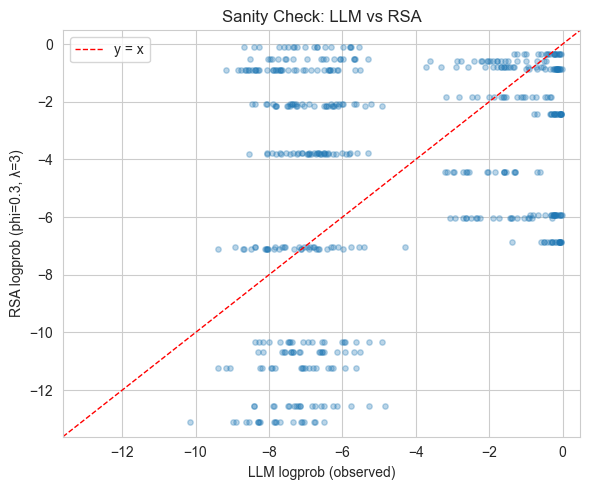

Pearson r = 0.326


In [46]:
import matplotlib.pyplot as plt

# ── Sanity Check: LLM logprob vs RSA 예측 (phi=0.3, λ=3) ────────────────────
phi_test, lam_test = 0.3, 3.0

rsa_preds = []
for _, row in df_long.iterrows():
    s_i   = state_to_idx.get(row["state"])
    u_i   = utt_to_idx.get(row["utterance"])
    if s_i is None or u_i is None:
        rsa_preds.append(np.nan)
        continue
    probs = rsa_speaker(s_i, phi=phi_test, lam=lam_test)
    rsa_preds.append(np.log(probs[u_i] + 1e-10))

df_long["logprob_rsa"] = rsa_preds
df_plot = df_long.dropna(subset=["logprob_rsa"])

fig, ax = plt.subplots(figsize=(6, 5))
ax.scatter(df_plot["logprob_obs"], df_plot["logprob_rsa"], alpha=0.3, s=15)
lim = [min(df_plot["logprob_obs"].min(), df_plot["logprob_rsa"].min()) - 0.5,
       max(df_plot["logprob_obs"].max(), df_plot["logprob_rsa"].max()) + 0.5]
ax.plot(lim, lim, "r--", linewidth=1, label="y = x")
ax.set_xlim(lim); ax.set_ylim(lim)
ax.set_xlabel("LLM logprob (observed)")
ax.set_ylabel("RSA logprob (phi=0.3, λ=3)")
ax.set_title("Sanity Check: LLM vs RSA")
ax.legend()
plt.tight_layout()
plt.savefig("plot_rsa_sanity.png", dpi=150)
plt.show()

corr = df_plot[["logprob_obs","logprob_rsa"]].corr().iloc[0, 1]
print(f"Pearson r = {corr:.3f}")

---
## Step 4 — PyMC: λ, φ 추정

```
de_rsa_data.csv → PyMC

priors:
  λ    ~ Uniform(0, 20)
  φ[r] ~ Uniform(0, 1)   for each relationship r
  c    ~ Normal(0, 5)
  σ    ~ HalfNormal(1)

likelihood:
  logprob_obs[i] ~ Normal(μ = λ·[(1-φ[r])·u_epi[i] + φ[r]·u_soc[i]] + c, σ)
```

**해석**:
- `φ[r]` 클수록 → 그 관계에서 social(polite) utility에 더 많이 의존
- 인간 논문 결과 (Table 4, pRRSAc): Close friend=0.45, Distant colleague=0.31, Easy-going boss=0.37, Dreaded boss=0.22

In [47]:
# ── scipy 호환성 패치 (gaussian이 signal.windows로 이동됨) ───────────────────
import scipy.signal
import scipy.signal.windows
if not hasattr(scipy.signal, "gaussian"):
    scipy.signal.gaussian = scipy.signal.windows.gaussian

import pymc as pm    # PyMC v4+
import arviz as az

# ── 데이터 준비 ───────────────────────────────────────────────────────────────
df_m = pd.read_csv("de_rsa_data.csv")

rel_cats   = pd.Categorical(df_m["relationship"], categories=RELATIONS)
rel_idx    = rel_cats.codes               # 0~3 (numpy array)
u_epi_arr  = df_m["u_epi"].values
u_soc_arr  = df_m["u_soc"].values
obs        = df_m["logprob_obs"].values

# ── PyMC Model ────────────────────────────────────────────────────────────────
with pm.Model() as rsa_model:

    # Priors
    lam   = pm.Uniform("lambda",  lower=0,  upper=20)
    phi   = pm.Uniform("phi",     lower=0,  upper=1,  shape=len(RELATIONS))  # φ per relationship
    c     = pm.Normal("c",        mu=0,     sigma=5)
    sigma = pm.HalfNormal("sigma", sigma=1)

    # Forward pass
    phi_r   = phi[rel_idx]                                  # per-observation phi
    utility = (1 - phi_r) * u_epi_arr + phi_r * u_soc_arr  # weighted utility
    mu      = lam * utility + c

    # Likelihood
    y_obs = pm.Normal("y_obs", mu=mu, sigma=sigma, observed=obs)

    # ── Test run (2000 samples) ──────────────────────────────────
    trace_test = pm.sample(2000, tune=1000, chains=4, target_accept=0.95,
                      progressbar=True, random_seed=42)

print(az.summary(trace_test, var_names=["lambda", "phi", "c", "sigma"]))

Auto-assigning NUTS sampler...
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [lambda, phi, c, sigma]


Sampling 4 chains for 1_000 tune and 2_000 draw iterations (4_000 + 8_000 draws total) took 6 seconds.


         mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  \
lambda  1.269  0.110   1.059    1.476      0.002    0.001    3750.0    4646.0   
phi[0]  0.813  0.057   0.708    0.922      0.001    0.001    2099.0    2627.0   
phi[1]  0.786  0.056   0.683    0.895      0.001    0.001    2171.0    2913.0   
phi[2]  0.815  0.057   0.709    0.924      0.001    0.001    2052.0    2273.0   
phi[3]  0.786  0.056   0.678    0.889      0.001    0.001    2202.0    2835.0   
c      -7.014  0.373  -7.714   -6.315      0.008    0.006    2271.0    3646.0   
sigma   2.722  0.086   2.563    2.887      0.001    0.001    5823.0    4497.0   

        r_hat  
lambda    1.0  
phi[0]    1.0  
phi[1]    1.0  
phi[2]    1.0  
phi[3]    1.0  
c         1.0  
sigma     1.0  


In [48]:
# ── pRRSAf Model ─────────────────────────────────────────────────────────────
# U(u, s, r) = U_epi(u,s) + α_r · U_soc(u)   ← φ로 비율 조정 대신, α로 가중치 덧붙임
# α_r ~ Uniform(0, 5)

with pm.Model() as rsa_model_f:

    lam_f   = pm.Uniform("lambda", lower=0, upper=20)
    alpha   = pm.Uniform("alpha",  lower=0, upper=5,  shape=len(RELATIONS))
    c_f     = pm.Normal("c",       mu=0,    sigma=5)
    sigma_f = pm.HalfNormal("sigma", sigma=1)

    alpha_r = alpha[rel_idx]
    utility_f = u_epi_arr + alpha_r * u_soc_arr
    mu_f      = lam_f * utility_f + c_f

    y_obs_f = pm.Normal("y_obs", mu=mu_f, sigma=sigma_f, observed=obs)

    trace_test_f = pm.sample(2000, tune=1000, chains=4, target_accept=0.95,
                      progressbar=True, random_seed=42)

print(az.summary(trace_test_f, var_names=["lambda", "alpha", "c", "sigma"]))


Auto-assigning NUTS sampler...
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [lambda, alpha, c, sigma]


Sampling 4 chains for 1_000 tune and 2_000 draw iterations (4_000 + 8_000 draws total) took 8 seconds.


           mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  \
lambda    0.271  0.043   0.200    0.351      0.001    0.001    1303.0   
alpha[0]  3.916  0.603   2.906    4.987      0.018    0.013    1136.0   
alpha[1]  3.681  0.600   2.587    4.780      0.017    0.012    1187.0   
alpha[2]  3.940  0.602   2.926    5.000      0.018    0.013    1061.0   
alpha[3]  3.703  0.596   2.623    4.790      0.017    0.012    1207.0   
c        -6.967  0.282  -7.466   -6.408      0.006    0.004    2242.0   
sigma     2.722  0.084   2.566    2.877      0.001    0.001    3922.0   

          ess_tail  r_hat  
lambda      3065.0    1.0  
alpha[0]    2113.0    1.0  
alpha[1]    2303.0    1.0  
alpha[2]    1596.0    1.0  
alpha[3]    2771.0    1.0  
c           3026.0    1.0  
sigma       3886.0    1.0  


Auto-assigning NUTS sampler...
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [lambda, phi, c, sigma]


Sampling 4 chains for 1_000 tune and 2_000 draw iterations (4_000 + 8_000 draws total) took 5 seconds.


         mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  \
lambda  1.269  0.110   1.059    1.476      0.002    0.001    3750.0    4646.0   
phi[0]  0.813  0.057   0.708    0.922      0.001    0.001    2099.0    2627.0   
phi[1]  0.786  0.056   0.683    0.895      0.001    0.001    2171.0    2913.0   
phi[2]  0.815  0.057   0.709    0.924      0.001    0.001    2052.0    2273.0   
phi[3]  0.786  0.056   0.678    0.889      0.001    0.001    2202.0    2835.0   
c      -7.014  0.373  -7.714   -6.315      0.008    0.006    2271.0    3646.0   
sigma   2.722  0.086   2.563    2.887      0.001    0.001    5823.0    4497.0   

        r_hat  
lambda    1.0  
phi[0]    1.0  
phi[1]    1.0  
phi[2]    1.0  
phi[3]    1.0  
c         1.0  
sigma     1.0  


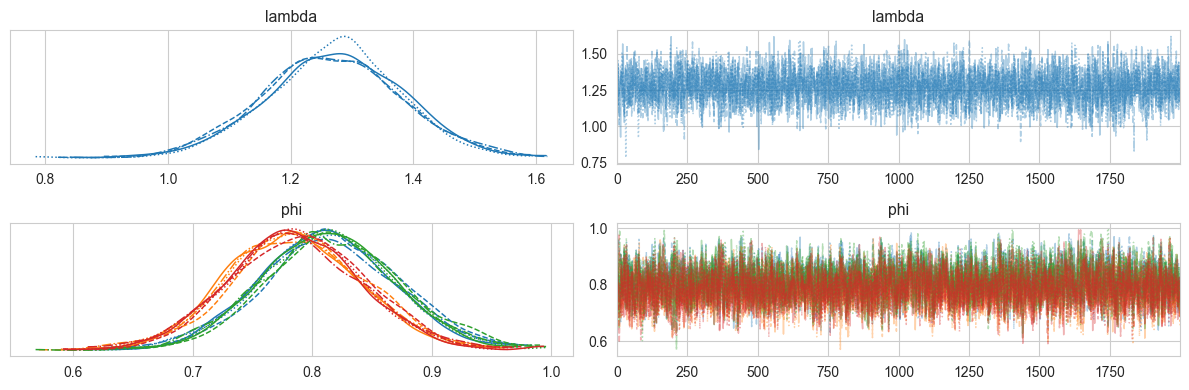

In [49]:
# ── Full Inference Run  ────────────────────────────────────────────────
with rsa_model:
    trace = pm.sample(2000, tune=1000, chains=4, target_accept=0.95,
                      progressbar=True, random_seed=42)

az.to_netcdf(trace, "trace_rsa.nc")
print(az.summary(trace, var_names=["lambda","phi","c","sigma"]))
az.plot_trace(trace, var_names=["lambda","phi"])
plt.tight_layout(); plt.savefig("plot_trace.png", dpi=150)

---
## Step 5 — 인간 데이터와 비교

| 비교 항목 | 소스 | 내용 |
|---|---|---|
| **φ 비교** | Table 4 | LLM 추정 φ vs 인간 fitted φ (rank order, 크기) |
| **Predicted mean state** | Table 3 | RSA 예측 평균 state vs 인간 실험 평균 state |
| **R²** | Table 5 | 모델 fit 품질 (논문: Close friend 0.79, Dreaded boss −0.2) |

> **Predicted mean state**: E[s ∣ u, r] = Σ_s [s · S(u∣s,r)] / Σ_s [S(u∣s,r)]  
> 어떤 단어를 골랐을 때 그 상황의 기대 state — 인간과 LLM이 비슷한가?

In [50]:
# ── 인간 레퍼런스 파라미터 (논문 Table 3 & Table 4, pRRSAc) ──────────────────
# 관계 이름 매핑: 논문(EN) → 실험(DE)
REL_MAP = {
    "Close friend":      "Enge Freundin",
    "Distant colleague": "Entfernte Kollegin",
    "Easy-going boss":   "Lockere Chefin",
    "Dreaded boss":      "Gefürchtete Chefin",
}

# Table 4 — pRRSAc MAP estimates
HUMAN_LAM  = 4.59
HUMAN_PHI  = {
    "Enge Freundin":      0.45,   # Close friend
    "Entfernte Kollegin": 0.31,   # Distant colleague
    "Lockere Chefin":     0.37,   # Easy-going boss
    "Gefürchtete Chefin": 0.22,   # Dreaded boss
}

# Table 4 — pRRSAc Values estimates (논문 Table 5 R² 산출에 사용된 파라미터)
HUMAN_LAM_VAL  = 3.40
HUMAN_PHI_VAL  = {
    "Enge Freundin":      0.58,
    "Entfernte Kollegin": 0.47,
    "Lockere Chefin":     0.56,
    "Gefürchtete Chefin": 0.34,
}

# Table 3 — Experiment 3 human speaker mean state per (relationship, utterance)
HUMAN_TABLE3 = {
    ("Enge Freundin",      "großartig"):   4.80,
    ("Enge Freundin",      "gut"):         3.31,
    ("Enge Freundin",      "okay"):        2.38,
    ("Enge Freundin",      "schlecht"):    1.12,
    ("Enge Freundin",      "schrecklich"): 1.18,
    ("Entfernte Kollegin", "großartig"):   4.31,
    ("Entfernte Kollegin", "gut"):         2.91,
    ("Entfernte Kollegin", "okay"):        2.04,
    ("Entfernte Kollegin", "schlecht"):    1.26,
    ("Entfernte Kollegin", "schrecklich"): 1.04,
    ("Lockere Chefin",     "großartig"):   4.46,
    ("Lockere Chefin",     "gut"):         3.27,
    ("Lockere Chefin",     "okay"):        2.30,
    ("Lockere Chefin",     "schlecht"):    1.25,
    ("Lockere Chefin",     "schrecklich"): 1.07,
    ("Gefürchtete Chefin", "großartig"):   3.69,
    ("Gefürchtete Chefin", "gut"):         2.59,
    ("Gefürchtete Chefin", "okay"):        1.67,
    ("Gefürchtete Chefin", "schlecht"):    1.19,
    ("Gefürchtete Chefin", "schrecklich"): 1.11,
}

# Table 5 — pRRSAc R² per relationship (논문 기준)
HUMAN_R2 = {
    "Enge Freundin":       0.79,
    "Lockere Chefin":      0.74,
    "Entfernte Kollegin":  0.78,
    "Gefürchtete Chefin": -0.20,
}

print("인간 레퍼런스 파라미터 로드 완료")
print(f"  λ_MAP = {HUMAN_LAM},  λ_Val = {HUMAN_LAM_VAL}")
print("  φ per relationship (pRRSAc):")
print(f"  {'':22s}  {'MAP':>6}  {'Val':>6}")
for rel in HUMAN_PHI:
    print(f"    {rel:22s}: {HUMAN_PHI[rel]:5.2f}  {HUMAN_PHI_VAL[rel]:5.2f}")
# Table 4 — pRRSAf MAP estimates (α per relationship)
HUMAN_ALPHA = {
    "Enge Freundin":      1.88,   # Close friend
    "Entfernte Kollegin": 2.90,   # Distant colleague
    "Lockere Chefin":     1.97,   # Easy-going boss
    "Gefürchtete Chefin": 4.63,   # Dreaded boss
}
HUMAN_LAM_F = 2.25   # λ for pRRSAf

print("  α per relationship (pRRSAf):")
for rel, a in HUMAN_ALPHA.items():
    print(f"    {rel:22s}: {a}")


인간 레퍼런스 파라미터 로드 완료
  λ_MAP = 4.59,  λ_Val = 3.4
  φ per relationship (pRRSAc):
                             MAP     Val
    Enge Freundin         :  0.45   0.58
    Entfernte Kollegin    :  0.31   0.47
    Lockere Chefin        :  0.37   0.56
    Gefürchtete Chefin    :  0.22   0.34
  α per relationship (pRRSAf):
    Enge Freundin         : 1.88
    Entfernte Kollegin    : 2.9
    Lockere Chefin        : 1.97
    Gefürchtete Chefin    : 4.63


pRRSAc — φ 비교
  λ  LLM=1.27  Human=4.59
  Enge Freundin         : LLM=0.813  Human=0.450
  Entfernte Kollegin    : LLM=0.786  Human=0.310
  Lockere Chefin        : LLM=0.815  Human=0.370
  Gefürchtete Chefin    : LLM=0.786  Human=0.220

pRRSAf — α 비교
  λ  LLM=0.27  Human=2.25
  Enge Freundin         : LLM=3.916  Human=1.880
  Entfernte Kollegin    : LLM=3.681  Human=2.900
  Lockere Chefin        : LLM=3.940  Human=1.970
  Gefürchtete Chefin    : LLM=3.703  Human=4.630


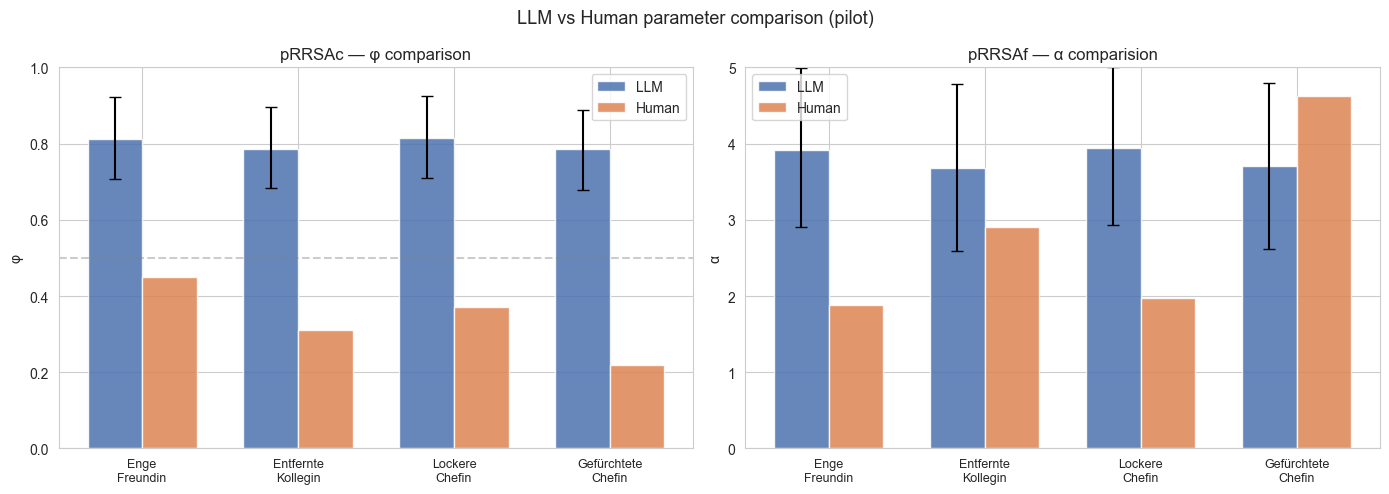

저장 완료 → plot_phi_alpha_comparison.png


In [51]:
import matplotlib.pyplot as plt
import numpy as np

# ── pRRSAc: φ 추출 ────────────────────────────────────────────────────────────
summary_c = az.summary(trace_test, var_names=["lambda", "phi"])
lam_llm   = summary_c.loc["lambda", "mean"]
phi_llm   = {rel: summary_c.loc[f"phi[{i}]", "mean"] for i, rel in enumerate(RELATIONS)}
phi_lo    = [summary_c.loc[f"phi[{i}]", "hdi_3%"]  for i in range(len(RELATIONS))]
phi_hi    = [summary_c.loc[f"phi[{i}]", "hdi_97%"] for i in range(len(RELATIONS))]

# ── pRRSAf: α 추출 ────────────────────────────────────────────────────────────
summary_f  = az.summary(trace_test_f, var_names=["lambda", "alpha"])
lam_llm_f  = summary_f.loc["lambda", "mean"]
alpha_llm  = {rel: summary_f.loc[f"alpha[{i}]", "mean"] for i, rel in enumerate(RELATIONS)}
alpha_lo   = [summary_f.loc[f"alpha[{i}]", "hdi_3%"]  for i in range(len(RELATIONS))]
alpha_hi   = [summary_f.loc[f"alpha[{i}]", "hdi_97%"] for i in range(len(RELATIONS))]

# 콘솔 출력
print("=" * 55)
print("pRRSAc — φ 비교")
print(f"  λ  LLM={lam_llm:.2f}  Human={HUMAN_LAM}")
for rel in RELATIONS:
    print(f"  {rel:22s}: LLM={phi_llm[rel]:.3f}  Human={HUMAN_PHI[rel]:.3f}")

print("\npRRSAf — α 비교")
print(f"  λ  LLM={lam_llm_f:.2f}  Human={HUMAN_LAM_F}")
for rel in RELATIONS:
    print(f"  {rel:22s}: LLM={alpha_llm[rel]:.3f}  Human={HUMAN_ALPHA[rel]:.3f}")

# ── 시각화 ────────────────────────────────────────────────────────────────────
labels = ["Enge\nFreundin", "Entfernte\nKollegin", "Lockere\nChefin", "Gefürchtete\nChefin"]
x = np.arange(len(RELATIONS))
w = 0.35

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 왼쪽: pRRSAc φ
ax = axes[0]
ax.bar(x - w/2, [phi_llm[r]   for r in RELATIONS], w, label="LLM",   color="#4C72B0", alpha=0.85)
ax.bar(x + w/2, [HUMAN_PHI[r] for r in RELATIONS], w, label="Human", color="#DD8452", alpha=0.85)
ax.errorbar(x - w/2, [phi_llm[r] for r in RELATIONS],
            yerr=[[phi_llm[r]-phi_lo[i] for i,r in enumerate(RELATIONS)],
                  [phi_hi[i]-phi_llm[r] for i,r in enumerate(RELATIONS)]],
            fmt="none", color="black", capsize=4)
ax.set_xticks(x); ax.set_xticklabels(labels, fontsize=9)
ax.set_ylim(0, 1); ax.set_ylabel("φ"); ax.set_title("pRRSAc — φ comparison", fontsize=12)
ax.axhline(0.5, color="gray", linestyle="--", alpha=0.4)
ax.legend()

# 오른쪽: pRRSAf α
ax = axes[1]
ax.bar(x - w/2, [alpha_llm[r]   for r in RELATIONS], w, label="LLM",   color="#4C72B0", alpha=0.85)
ax.bar(x + w/2, [HUMAN_ALPHA[r] for r in RELATIONS], w, label="Human", color="#DD8452", alpha=0.85)
ax.errorbar(x - w/2, [alpha_llm[r] for r in RELATIONS],
            yerr=[[alpha_llm[r]-alpha_lo[i] for i,r in enumerate(RELATIONS)],
                  [alpha_hi[i]-alpha_llm[r] for i,r in enumerate(RELATIONS)]],
            fmt="none", color="black", capsize=4)
ax.set_xticks(x); ax.set_xticklabels(labels, fontsize=9)
ax.set_ylim(0, 5); ax.set_ylabel("α"); ax.set_title("pRRSAf — α comparision", fontsize=12)
ax.legend()

plt.suptitle("LLM vs Human parameter comparison (pilot)", fontsize=13)
plt.tight_layout()
plt.savefig("plot_phi_alpha_comparison.png", dpi=150)
plt.show()
print("저장 완료 → plot_phi_alpha_comparison.png")


/var/folders/fc/wq_gjk3n0dx253618rmsgxy00000gn/T/ipykernel_28236/2295092937.py:55: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(UTTERANCES, rotation=25, ha="right", fontsize=9)
/var/folders/fc/wq_gjk3n0dx253618rmsgxy00000gn/T/ipykernel_28236/2295092937.py:55: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(UTTERANCES, rotation=25, ha="right", fontsize=9)
/var/folders/fc/wq_gjk3n0dx253618rmsgxy00000gn/T/ipykernel_28236/2295092937.py:55: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(UTTERANCES, rotation=25, ha="right", fontsize=9)
/var/folders/fc/wq_gjk3n0dx253618rmsgxy00000gn/T/ipykernel_28236/2295092937.py:55: UserWarning: set_ticklabels() should only be used with a fixed number of t

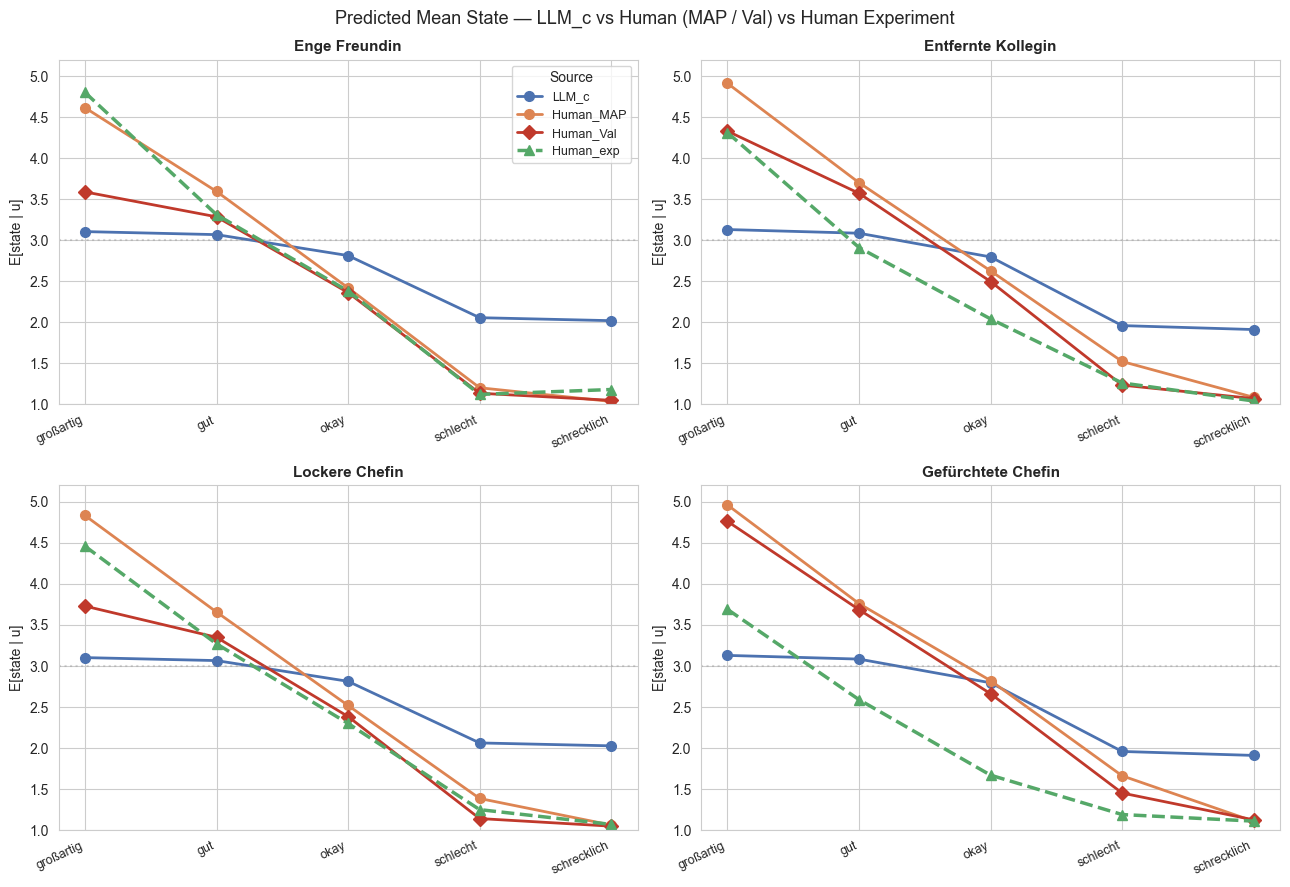

저장 완료 → plot_pred_mean_state.png


In [57]:
# ── Predicted Mean State: E[s | u, r] ────────────────────────────────────────
# pRRSAc: rsa_speaker(s_idx, phi, lam)
# pRRSAf: rsa_speaker_f(s_idx, alpha, lam)


def compute_pred_mean(phi_dict, lam, model="c"):
    rows = []
    for rel in RELATIONS:
        param = phi_dict[rel]
        speaker_fn = rsa_speaker if model == "c" else rsa_speaker_f
        speaker_mat = np.stack([speaker_fn(s_i, param, lam) for s_i in range(len(STATES))])
        for u_i, utt in enumerate(UTTERANCES):
            s_probs = speaker_mat[:, u_i]
            denom   = s_probs.sum()
            pred    = (np.array(STATES) * s_probs).sum() / denom if denom > 0 else np.nan
            rows.append({"relationship": rel, "utterance": utt, "pred_mean": pred})
    return pd.DataFrame(rows)

# 각 소스별 예측
df_llm_c   = compute_pred_mean(phi_llm,    lam_llm,   model="c");  df_llm_c["source"]   = "LLM_c"
df_llm_f   = compute_pred_mean(alpha_llm,  lam_llm_f, model="f");  df_llm_f["source"]   = "LLM_f"
df_human_c = compute_pred_mean(HUMAN_PHI,  HUMAN_LAM, model="c");  df_human_c["source"] = "Human_MAP"
df_human_v = compute_pred_mean(HUMAN_PHI_VAL, HUMAN_LAM_VAL, model="c"); df_human_v["source"] = "Human_Val"
df_human_f = compute_pred_mean(HUMAN_ALPHA,HUMAN_LAM_F,model="f"); df_human_f["source"] = "Human_f"

table3_rows = [{"relationship": r, "utterance": u, "pred_mean": v, "source": "Human_exp"}
               for (r,u), v in HUMAN_TABLE3.items()]
df_all = pd.concat([df_llm_c, df_llm_f, df_human_c, df_human_v, df_human_f,
                    pd.DataFrame(table3_rows)], ignore_index=True)

# ── 시각화: LLM_c, Human_MAP, Human_Val, Human_exp ──────────────────────────
import seaborn as sns

plot_sources = ["LLM_c", "Human_MAP", "Human_Val", "Human_exp"]
df_plot = df_all[df_all["source"].isin(plot_sources)]

palette = {"LLM_c":"#4C72B0", "Human_MAP":"#DD8452", "Human_Val":"#C0392B", "Human_exp":"#55A868"}
markers = {"LLM_c":"o", "Human_MAP":"o", "Human_Val":"D", "Human_exp":"^"}
lw      = {"LLM_c":2, "Human_MAP":2, "Human_Val":2, "Human_exp":2.5}

fig, axes = plt.subplots(2, 2, figsize=(13, 9))
axes = axes.flatten()

for ax, rel in zip(axes, RELATIONS):
    df_rel = df_plot[df_plot["relationship"] == rel]
    for src in plot_sources:
        grp = df_rel[df_rel["source"] == src]
        grp_s = grp.set_index("utterance").reindex(UTTERANCES).reset_index()
        ax.plot(UTTERANCES, grp_s["pred_mean"],
                marker=markers[src], label=src, color=palette[src],
                linewidth=lw[src], markersize=7,
                linestyle="--" if src == "Human_exp" else "-")
    ax.set_title(rel, fontsize=11, fontweight="bold")
    ax.set_ylim(1, 5.2); ax.set_ylabel("E[state | u]")
    ax.set_xticklabels(UTTERANCES, rotation=25, ha="right", fontsize=9)
    ax.axhline(3, color="gray", linestyle=":", alpha=0.3)

axes[0].legend(title="Source", fontsize=9, loc="upper right")
fig.suptitle("Predicted Mean State — LLM_c vs Human (MAP / Val) vs Human Experiment", fontsize=13)
plt.tight_layout()
plt.savefig("plot_pred_mean_state.png", dpi=150)
plt.show()
print("저장 완료 → plot_pred_mean_state.png")

/var/folders/fc/wq_gjk3n0dx253618rmsgxy00000gn/T/ipykernel_28236/2434019869.py:61: UserWarning: You passed a edgecolor/edgecolors ('white') for an unfilled marker ('+').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  ax.scatter(
/var/folders/fc/wq_gjk3n0dx253618rmsgxy00000gn/T/ipykernel_28236/2434019869.py:61: UserWarning: You passed a edgecolor/edgecolors ('white') for an unfilled marker ('+').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  ax.scatter(
/var/folders/fc/wq_gjk3n0dx253618rmsgxy00000gn/T/ipykernel_28236/2434019869.py:61: UserWarning: You passed a edgecolor/edgecolors ('white') for an unfilled marker ('+').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  ax.scatter(


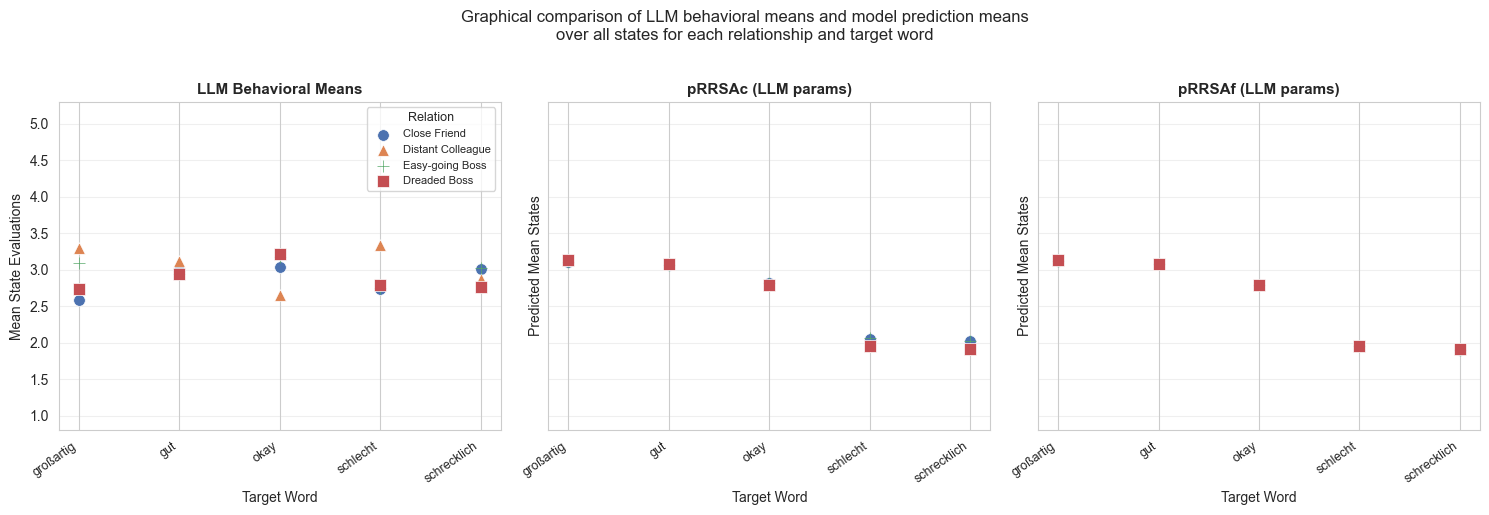

저장 완료 → plot_fig1_comparison.png


In [53]:
# ── Figure 1 style: LLM Behavioral Means vs pRRSAc vs pRRSAf ─────────────────
# Left:   LLM 실험 데이터에서 직접 계산한 E[s|u,r] (= behavioral means)
# Center: pRRSAc 모델 예측 (LLM MAP params)
# Right:  pRRSAf 모델 예측 (LLM MAP params)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ── 1) LLM behavioral means: E[s|u,r] from raw logit probabilities ──────────
df_raw = pd.read_csv("de_logit_results.csv")
prob_cols = [c for c in df_raw.columns if c.startswith("prob_")]

# (relationship, state) 별 situation 평균 prob
df_avg = df_raw.groupby(["relationship", "state"])[prob_cols].mean().reset_index()

# E[s|u,r] = Σ_s  s·P(u|s,r) / Σ_s P(u|s,r)   (uniform prior over s)
behav_rows = []
for rel in RELATIONS:
    for utt in UTTERANCES:
        pcol = f"prob_{utt}"
        sub = df_avg[df_avg["relationship"] == rel].sort_values("state")
        states = sub["state"].values.astype(float)
        probs  = sub[pcol].values
        denom  = probs.sum()
        e_s    = (states * probs).sum() / denom if denom > 0 else np.nan
        behav_rows.append({"relationship": rel, "utterance": utt, "pred_mean": e_s})
df_behav = pd.DataFrame(behav_rows)

# ── 2) 3-panel figure ───────────────────────────────────────────────────────
rel_colors = {
    "Enge Freundin":       "#4C72B0",
    "Entfernte Kollegin":  "#DD8452",
    "Gefürchtete Chefin":  "#C44E52",
    "Lockere Chefin":      "#55A868",
}
rel_markers = {
    "Enge Freundin":       "o",
    "Entfernte Kollegin":  "^",
    "Gefürchtete Chefin":  "s",
    "Lockere Chefin":      "+",
}
rel_labels = {
    "Enge Freundin":       "Close Friend",
    "Entfernte Kollegin":  "Distant Colleague",
    "Gefürchtete Chefin":  "Dreaded Boss",
    "Lockere Chefin":      "Easy-going Boss",
}

datasets = [
    ("LLM Behavioral Means",   df_behav,   "Mean State Evaluations"),
    ("pRRSAc (LLM params)",    df_llm_c,   "Predicted Mean States"),
    ("pRRSAf (LLM params)",    df_llm_f,   "Predicted Mean States"),
]

fig, axes = plt.subplots(1, 3, figsize=(15, 5), sharey=True)

for ax, (title, df_src, ylabel) in zip(axes, datasets):
    for rel in RELATIONS:
        sub = df_src[df_src["relationship"] == rel].set_index("utterance").reindex(UTTERANCES)
        ax.scatter(
            range(len(UTTERANCES)), sub["pred_mean"].values,
            color=rel_colors[rel], marker=rel_markers[rel],
            s=70, label=rel_labels[rel], zorder=3, edgecolors="white", linewidths=0.5
        )
    ax.set_xticks(range(len(UTTERANCES)))
    ax.set_xticklabels(UTTERANCES, rotation=35, ha="right", fontsize=9)
    ax.set_title(title, fontsize=11, fontweight="bold")
    ax.set_ylabel(ylabel, fontsize=10)
    ax.set_ylim(0.8, 5.3)
    ax.set_xlabel("Target Word", fontsize=10)
    ax.grid(axis="y", alpha=0.3)

axes[0].legend(title="Relation", fontsize=8, title_fontsize=9, loc="upper right")

fig.suptitle(
    "Graphical comparison of LLM behavioral means and model prediction means\n"
    "over all states for each relationship and target word",
    fontsize=12, y=1.02
)
plt.tight_layout()
plt.savefig("plot_fig1_comparison.png", dpi=150, bbox_inches="tight")
plt.show()
print("저장 완료 → plot_fig1_comparison.png")

Relationship               LLM_c     LLM_f   Hum_MAP   Hum_Val
  Enge Freundin              0.510     0.554     0.985     0.845
  Entfernte Kollegin         0.547     0.546     0.804     0.910
  Lockere Chefin             0.539     0.595     0.956     0.931
  Gefürchtete Chefin         0.356     0.356     0.044     0.282
------------------------------------------------------------------------
  논문 Table 5 (참고):     0.790    0.780    0.740   -0.200 


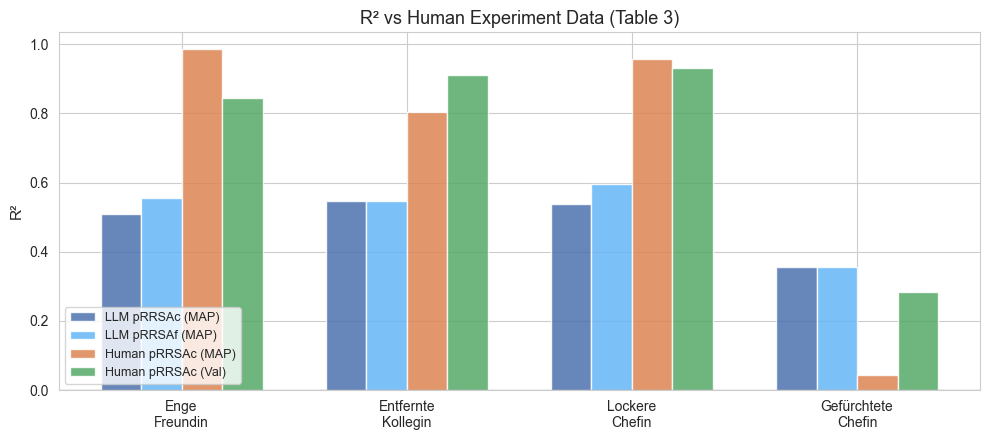

저장 완료 → plot_r2_comparison.png


In [54]:
# ── R² 계산: LLM 예측 vs Human_exp (Table 3) ─────────────────────────────────
# Human_MAP: MAP 파라미터(λ=4.59)로 RSA 예측 → Table 3과 비교
# Human_Val: Values 파라미터(λ=3.40)로 RSA 예측 → Table 3과 비교 (= 논문 Table 5)

def r2_score(y_true, y_pred):
    ss_res = ((y_true - y_pred) ** 2).sum()
    ss_tot = ((y_true - y_true.mean()) ** 2).sum()
    return float(1 - ss_res / ss_tot) if ss_tot > 0 else 0.0

# Human_Val 예측 계산 (Values 파라미터 사용)
df_human_val = compute_pred_mean(HUMAN_PHI_VAL, HUMAN_LAM_VAL, model="c")

print("=" * 72)
print(f"{'Relationship':22s}  {'LLM_c':>8}  {'LLM_f':>8}  {'Hum_MAP':>8}  {'Hum_Val':>8}")
print("=" * 72)

r2_rows = []
for rel in RELATIONS:
    human_exp = np.array([HUMAN_TABLE3.get((rel, u), np.nan) for u in UTTERANCES])
    llm_c_v   = df_llm_c[  df_llm_c["relationship"]   == rel].set_index("utterance").reindex(UTTERANCES)["pred_mean"].values
    llm_f_v   = df_llm_f[  df_llm_f["relationship"]   == rel].set_index("utterance").reindex(UTTERANCES)["pred_mean"].values
    hum_c_v   = df_human_c[df_human_c["relationship"] == rel].set_index("utterance").reindex(UTTERANCES)["pred_mean"].values
    hum_v_v   = df_human_val[df_human_val["relationship"] == rel].set_index("utterance").reindex(UTTERANCES)["pred_mean"].values

    mask = ~np.isnan(human_exp)
    r2_c  = r2_score(human_exp[mask], llm_c_v[mask])
    r2_f  = r2_score(human_exp[mask], llm_f_v[mask])
    r2_hc = r2_score(human_exp[mask], hum_c_v[mask])
    r2_hv = r2_score(human_exp[mask], hum_v_v[mask])

    r2_rows.append({"relationship": rel, "LLM_c": r2_c, "LLM_f": r2_f,
                    "Human_MAP": r2_hc, "Human_Val": r2_hv})
    print(f"  {rel:22s}  {r2_c:8.3f}  {r2_f:8.3f}  {r2_hc:8.3f}  {r2_hv:8.3f}")

print("-" * 72)
print(f"  논문 Table 5 (참고):  ", end="")
for rel in RELATIONS:
    print(f" {HUMAN_R2.get(rel, 0):7.3f} ", end="")
print()

df_r2 = pd.DataFrame(r2_rows)

# ── 시각화 ────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 4.5))
x = np.arange(len(RELATIONS))
w = 0.18
short = ["Enge\nFreundin","Entfernte\nKollegin","Lockere\nChefin","Gefürchtete\nChefin"]

ax.bar(x - 1.5*w, df_r2["LLM_c"],     w, label="LLM pRRSAc (MAP)",    color="#4C72B0", alpha=0.85)
ax.bar(x - 0.5*w, df_r2["LLM_f"],     w, label="LLM pRRSAf (MAP)",    color="#64B5F6", alpha=0.85)
ax.bar(x + 0.5*w, df_r2["Human_MAP"],  w, label="Human pRRSAc (MAP)",  color="#DD8452", alpha=0.85)
ax.bar(x + 1.5*w, df_r2["Human_Val"],  w, label="Human pRRSAc (Val)",  color="#55A868", alpha=0.85)

ax.axhline(0, color="black", linewidth=0.8)
ax.set_xticks(x); ax.set_xticklabels(short, fontsize=10)
ax.set_ylabel("R²", fontsize=11)
ax.set_title("R² vs Human Experiment Data (Table 3)", fontsize=13)
ax.legend(fontsize=9, loc="lower left")
plt.tight_layout()
plt.savefig("plot_r2_comparison.png", dpi=150)
plt.show()
print("저장 완료 → plot_r2_comparison.png")

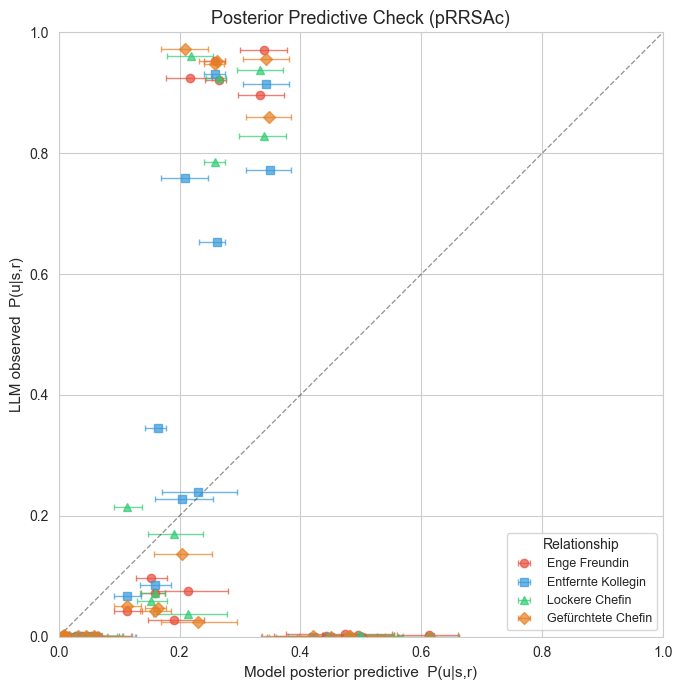

Pearson r = 0.223
총 100개 조합
저장 완료 → plot_posterior_predictive.png


In [55]:
# ── Posterior Predictive Check: Yoon (2016) style ────────────────────────────
# x축: RSA posterior predictive P(u|s,r) — MCMC 샘플마다 다른 예측
# y축: LLM 관측 P(u|s,r) — de_logit_results.csv에서 추출
# 점 하나 = (utterance, state, relationship) 한 조합

import matplotlib.pyplot as plt
import numpy as np

# ── 1. LLM 관측 확률 준비 ────────────────────────────────────────────────────
# logprob → prob 변환 (softmax 이미 적용된 값이므로 exp만)
df_obs = pd.read_csv("de_rsa_data.csv")

# (state, relationship, utterance)별 관측 logprob → prob
df_obs["prob_obs"] = np.exp(df_obs["logprob_obs"])

# ── 2. Posterior predictive 계산 (pRRSAc) ────────────────────────────────────
# trace_test에서 posterior 샘플 추출
posterior = trace_test.posterior
lam_samples = posterior["lambda"].values.flatten()   # (n_samples,)
phi_samples = posterior["phi"].values.reshape(-1, len(RELATIONS))  # (n_samples, 4)

n_samples = len(lam_samples)

# 각 관측값에 대해 posterior predictive 분포 계산
combos = df_obs.groupby(["state", "relationship", "utterance"]).first().reset_index()

ppc_rows = []
for _, row in combos.iterrows():
    s_i = state_to_idx[row["state"]]
    u_i = utt_to_idx[row["utterance"]]
    r_i = RELATIONS.index(row["relationship"])

    # 각 posterior sample에서 S(u|s,r) 계산
    preds = []
    for j in range(n_samples):
        probs = rsa_speaker(s_i, phi=phi_samples[j, r_i], lam=lam_samples[j])
        preds.append(probs[u_i])
    preds = np.array(preds)

    ppc_rows.append({
        "state":        row["state"],
        "relationship": row["relationship"],
        "utterance":    row["utterance"],
        "prob_obs":     row["prob_obs"],
        "pred_mean":    preds.mean(),
        "pred_lo":      np.percentile(preds, 3),
        "pred_hi":      np.percentile(preds, 97),
    })

df_ppc = pd.DataFrame(ppc_rows)

# ── 3. 시각화 ────────────────────────────────────────────────────────────────
rel_colors = {
    "Enge Freundin":      "#E74C3C",   # 빨강
    "Entfernte Kollegin": "#3498DB",   # 파랑
    "Lockere Chefin":     "#2ECC71",   # 초록
    "Gefürchtete Chefin": "#E67E22",   # 주황
}
rel_markers = {
    "Enge Freundin":      "o",
    "Entfernte Kollegin": "s",
    "Lockere Chefin":     "^",
    "Gefürchtete Chefin": "D",
}

fig, ax = plt.subplots(figsize=(7, 7))

for rel in RELATIONS:
    df_r = df_ppc[df_ppc["relationship"] == rel]
    ax.errorbar(
        df_r["pred_mean"], df_r["prob_obs"],
        xerr=[df_r["pred_mean"] - df_r["pred_lo"],
              df_r["pred_hi"] - df_r["pred_mean"]],
        fmt=rel_markers[rel], color=rel_colors[rel],
        label=rel, alpha=0.7, markersize=6, capsize=2, linewidth=1,
    )

# 대각선
ax.plot([0, 1], [0, 1], "k--", alpha=0.4, linewidth=1)
ax.set_xlim(0, 1); ax.set_ylim(0, 1)
ax.set_xlabel("Model posterior predictive  P(u|s,r)", fontsize=11)
ax.set_ylabel("LLM observed  P(u|s,r)", fontsize=11)
ax.set_title("Posterior Predictive Check (pRRSAc)", fontsize=13)
ax.legend(title="Relationship", fontsize=9)
ax.set_aspect("equal")
plt.tight_layout()
plt.savefig("plot_posterior_predictive.png", dpi=150)
plt.show()

# ── 상관계수 ─────────────────────────────────────────────────────────────────
r = np.corrcoef(df_ppc["pred_mean"], df_ppc["prob_obs"])[0, 1]
print(f"Pearson r = {r:.3f}")
print(f"총 {len(df_ppc)}개 조합")
print("저장 완료 → plot_posterior_predictive.png")
